# PSDCodec Demo Deployment

This notebook is the single deployment-facing demo for the repository. It loads the canonical `demo` export, runs the ONNX encoder boundary with the server-side decoder, inspects the manuscript's illustrative task on one real campaign frame, and then evaluates a batch of campaign frames for deployment readiness.

Run `.venv/bin/python scripts/jobs/train_demo.py` first, then execute this notebook with the repository `.venv` kernel.


## What This Notebook Shows

1. Load the exported `demo` artifacts and the manuscript task configuration saved with them.
2. Run one end-to-end deployment round trip on a real campaign PSD frame.
3. Inspect the illustrative task breakdown for `preprocessing-only` and `full codec` reconstructions.
4. Plot PSD curves, occupancy curves, and extracted manuscript features.
5. Evaluate a batch of campaign frames, summarize bitrate and distortion, and build a reconstruction gallery.


In [1]:
import os
import sys
import tempfile
from pathlib import Path

candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
project_root = next(root for root in candidate_roots if (root / "src").exists())
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "psdcodec_mpl"))

project_root


PosixPath('/home/marti/Code/PSDCodec')

In [2]:
import importlib.util
import sys

missing_packages = [
    package_name
    for package_name in ("torch", "onnxruntime")
    if importlib.util.find_spec(package_name) is None
]
if missing_packages:
    raise RuntimeError(
        "Notebook dependencies are missing from the active kernel: "
        f"{missing_packages}. Run this notebook with the repository .venv kernel. "
        f"Current executable: {sys.executable}"
    )


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from interfaces.deployment import (
    create_deployment_service,
    evaluate_deployment_batch,
    load_campaign_frame_sample,
    select_gallery_frames,
)
from objectives.distortion import build_illustrative_task_breakdown


def to_db(values: np.ndarray) -> np.ndarray:
    """Convert linear power to dB for visualization."""
    return 10.0 * np.log10(np.clip(values, 1.0e-12, None))


In [4]:
export_dir = project_root / "models" / "exports" / "demo"
if not export_dir.exists():
    raise FileNotFoundError(
        "Missing models/exports/demo. Run `.venv/bin/python scripts/jobs/train_demo.py` first."
    )

service, artifacts = create_deployment_service(export_dir)
task_config = artifacts.experiment_config.task
if task_config is None:
    raise RuntimeError("The exported demo artifacts do not contain the manuscript task config.")
sample = load_campaign_frame_sample(artifacts, frame_index=0)
if sample.noise_floor is None:
    raise RuntimeError("The campaign-backed demo sample is missing its reference noise floor.")

{
    "export_dir": str(export_dir),
    "campaign_label": sample.campaign_label,
    "node_label": sample.node_label,
    "sequence_id": sample.sequence_id,
    "timestamp_ms": sample.timestamp_ms,
    "original_bin_count": int(sample.frame.size),
    "reduced_bin_count": (
        artifacts.runtime_config.preprocessing.resolve_reduced_bin_count(sample.frame.size)
    ),
    "onnx_path": str(artifacts.onnx_path),
    "checkpoint_path": str(artifacts.checkpoint_path),
}


{'export_dir': '/home/marti/Code/PSDCodec/models/exports/demo',
 'campaign_label': 'ANTENNA_sweep',
 'node_label': 'Node1',
 'sequence_id': 'ANTENNA_sweep/Node1',
 'timestamp_ms': 1773765849126,
 'original_bin_count': 4096,
 'reduced_bin_count': 512,
 'onnx_path': '/home/marti/Code/PSDCodec/models/exports/demo/encoder.onnx',
 'checkpoint_path': '/home/marti/Code/PSDCodec/models/checkpoints/demo/best.pt'}

In [5]:
evaluation = service.evaluate_frame(
    sample.frame,
    noise_floor=sample.noise_floor,
    frequency_grid_hz=sample.frequency_grid_hz,
    task_config=task_config,
)
decoded = service.decode_packet(evaluation.encode_result.packet_bytes)
assert np.allclose(decoded.reconstructed_frame, evaluation.encode_result.reconstructed_frame)

preprocessing_task = build_illustrative_task_breakdown(
    sample.frame,
    evaluation.encode_result.preprocessing_only_frame,
    noise_floor=sample.noise_floor,
    frequency_grid_hz=sample.frequency_grid_hz,
    config=task_config,
)
codec_task = build_illustrative_task_breakdown(
    sample.frame,
    evaluation.encode_result.reconstructed_frame,
    noise_floor=sample.noise_floor,
    frequency_grid_hz=sample.frequency_grid_hz,
    config=task_config,
)

single_frame_summary = {
    "packet_bytes": len(evaluation.encode_result.packet_bytes),
    "operational_bit_count": evaluation.encode_result.operational_bit_count,
    "rate_proxy_bit_count": evaluation.encode_result.rate_proxy_bit_count,
    "side_information_bit_count": evaluation.encode_result.packet.side_information_bit_count,
    "index_bit_count": evaluation.encode_result.packet.index_bit_count,
    "psd_distortion": evaluation.distortion.psd_distortion,
    "preprocessing_distortion": evaluation.distortion.preprocessing_distortion,
    "codec_distortion": evaluation.distortion.codec_distortion,
    "task_distortion": evaluation.distortion.task_distortion,
    "preprocessing_task_total": preprocessing_task.total_loss,
    "preprocessing_task_occ": preprocessing_task.occupancy_loss,
    "preprocessing_task_feat": preprocessing_task.feature_loss,
    "codec_task_total": codec_task.total_loss,
    "codec_task_occ": codec_task.occupancy_loss,
    "codec_task_feat": codec_task.feature_loss,
}
single_frame_summary


{'packet_bytes': 196,
 'operational_bit_count': 1333,
 'rate_proxy_bit_count': 1332.0605802213909,
 'side_information_bit_count': 352,
 'index_bit_count': 981,
 'psd_distortion': 0.21039758015377225,
 'preprocessing_distortion': 0.07895529038551632,
 'codec_distortion': 0.1285289246778649,
 'task_distortion': 2.078536017206906,
 'preprocessing_task_total': 2.777741579450603,
 'preprocessing_task_occ': 1.0247284404629,
 'preprocessing_task_feat': 1.753013138987703,
 'codec_task_total': 2.078536017206906,
 'codec_task_occ': 1.1421569840400605,
 'codec_task_feat': 0.9363790331668451}

In [6]:
feature_rows = [
    {
        "signal": "reference",
        "peak_frequency_mhz": (
            preprocessing_task.reference_features.peak_frequency_hz / 1.0e6
        ),
        "spectral_centroid_mhz": (
            preprocessing_task.reference_features.spectral_centroid_hz / 1.0e6
        ),
        "occupied_bandwidth_mhz": (
            preprocessing_task.reference_features.occupied_bandwidth_hz / 1.0e6
        ),
    },
    {
        "signal": "preprocessing_only",
        "peak_frequency_mhz": (
            preprocessing_task.reconstructed_features.peak_frequency_hz / 1.0e6
        ),
        "spectral_centroid_mhz": (
            preprocessing_task.reconstructed_features.spectral_centroid_hz / 1.0e6
        ),
        "occupied_bandwidth_mhz": (
            preprocessing_task.reconstructed_features.occupied_bandwidth_hz / 1.0e6
        ),
    },
    {
        "signal": "full_codec",
        "peak_frequency_mhz": (
            codec_task.reconstructed_features.peak_frequency_hz / 1.0e6
        ),
        "spectral_centroid_mhz": (
            codec_task.reconstructed_features.spectral_centroid_hz / 1.0e6
        ),
        "occupied_bandwidth_mhz": (
            codec_task.reconstructed_features.occupied_bandwidth_hz / 1.0e6
        ),
    },
]
feature_rows


[{'signal': 'reference',
  'peak_frequency_mhz': 105.8857421875,
  'spectral_centroid_mhz': 101.01975036288589,
  'occupied_bandwidth_mhz': 0.0},
 {'signal': 'preprocessing_only',
  'peak_frequency_mhz': 105.8759765625,
  'spectral_centroid_mhz': 101.03976402162776,
  'occupied_bandwidth_mhz': 0.068359375},
 {'signal': 'full_codec',
  'peak_frequency_mhz': 105.87109375,
  'spectral_centroid_mhz': 100.82898737866743,
  'occupied_bandwidth_mhz': 0.048828125}]

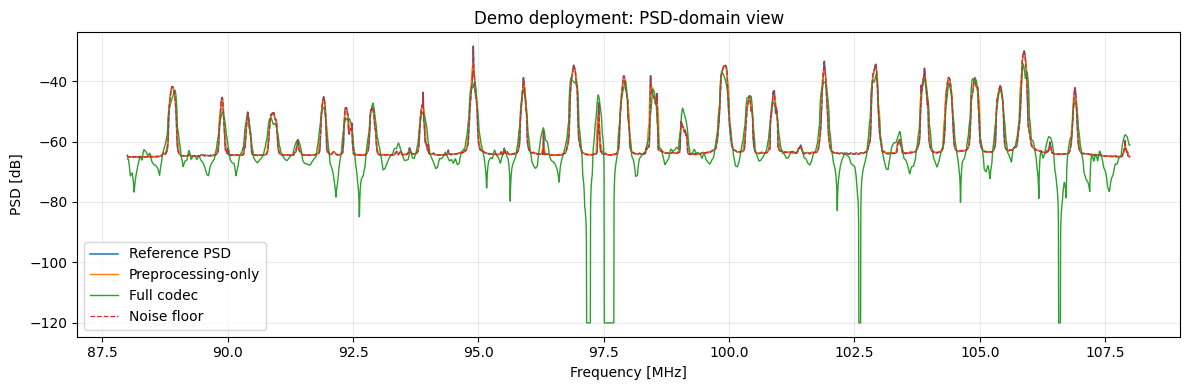

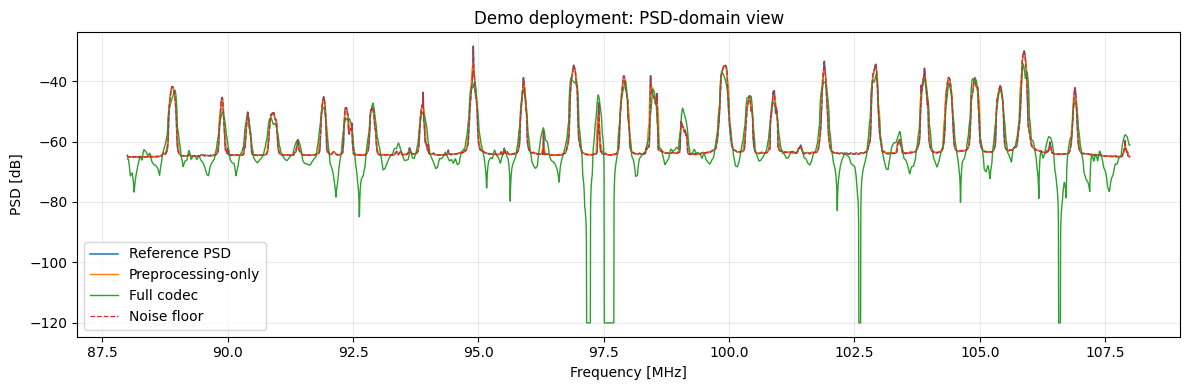

In [7]:
frequency_mhz = sample.frequency_grid_hz / 1.0e6
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(frequency_mhz, to_db(sample.frame), label="Reference PSD", linewidth=1.1)
ax.plot(
    frequency_mhz,
    to_db(evaluation.encode_result.preprocessing_only_frame),
    label="Preprocessing-only",
    linewidth=1.0,
)
ax.plot(
    frequency_mhz,
    to_db(evaluation.encode_result.reconstructed_frame),
    label="Full codec",
    linewidth=1.0,
)
ax.plot(
    frequency_mhz,
    to_db(sample.noise_floor),
    label="Noise floor",
    linewidth=0.9,
    linestyle="--",
)
ax.set_title("Demo deployment: PSD-domain view")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("PSD [dB]")
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig


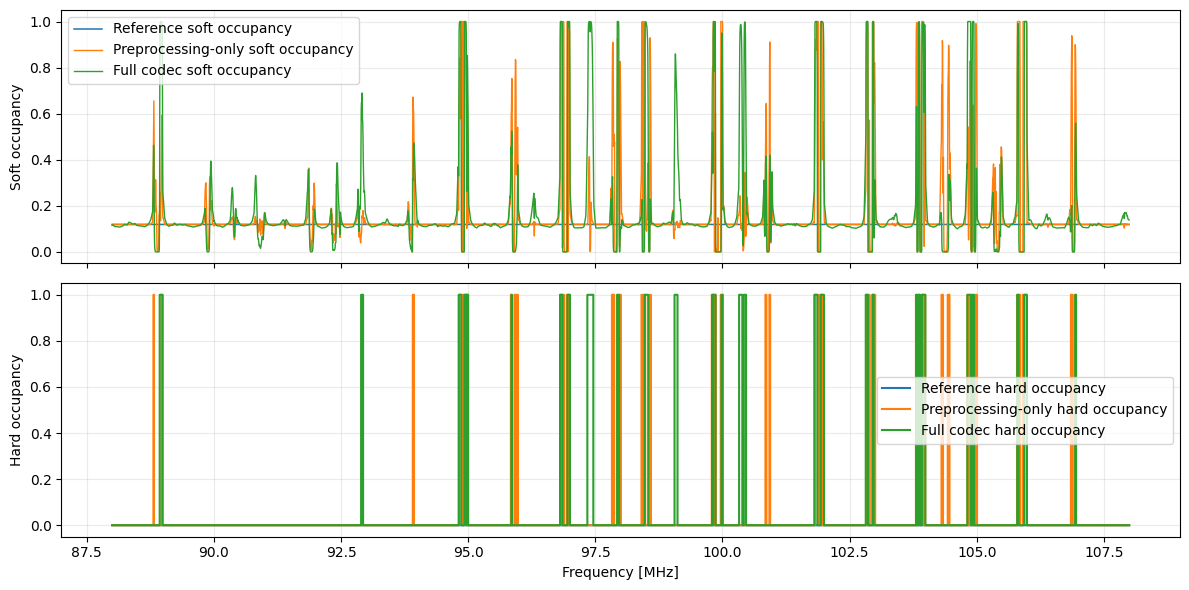

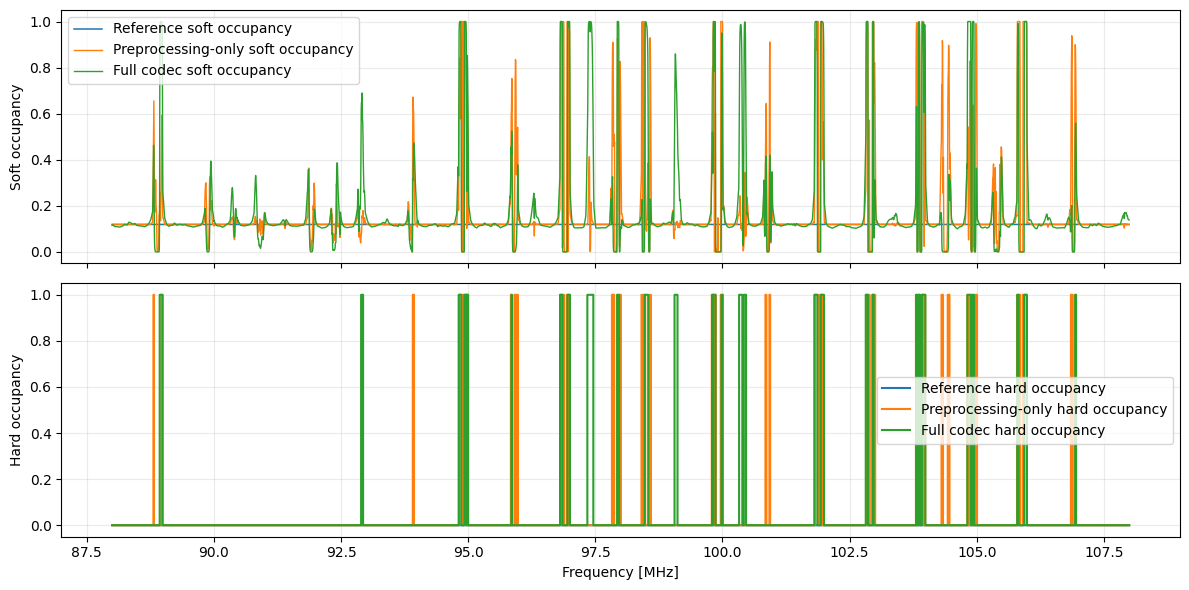

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(
    frequency_mhz,
    preprocessing_task.reference_soft_occupancy,
    label="Reference soft occupancy",
    linewidth=1.1,
)
axes[0].plot(
    frequency_mhz,
    preprocessing_task.reconstructed_soft_occupancy,
    label="Preprocessing-only soft occupancy",
    linewidth=1.0,
)
axes[0].plot(
    frequency_mhz,
    codec_task.reconstructed_soft_occupancy,
    label="Full codec soft occupancy",
    linewidth=1.0,
)
axes[0].set_ylabel("Soft occupancy")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].step(
    frequency_mhz,
    preprocessing_task.reference_hard_occupancy.astype(float),
    where="mid",
    label="Reference hard occupancy",
)
axes[1].step(
    frequency_mhz,
    preprocessing_task.reconstructed_hard_occupancy.astype(float),
    where="mid",
    label="Preprocessing-only hard occupancy",
)
axes[1].step(
    frequency_mhz,
    codec_task.reconstructed_hard_occupancy.astype(float),
    where="mid",
    label="Full codec hard occupancy",
)
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Hard occupancy")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig


## Batch Readiness

The single-frame view is useful for inspecting the manuscript task. The next cells evaluate a small batch of real campaign frames through the exact same deployment stack so the exported `demo` model can be judged as a deployment candidate rather than as one isolated example.


In [9]:
batch_frame_count = 24
batch_report = evaluate_deployment_batch(
    service,
    artifacts,
    max_frames=batch_frame_count,
    task_config=task_config,
)
batch_results = {
    "summary": batch_report.summary.to_display_dict(),
    "assessment": {
        "verdict": batch_report.assessment.verdict,
        "reasons": list(batch_report.assessment.reasons),
    },
}
batch_results


{'summary': {'frame_count': 24,
  'all_roundtrip_equal': True,
  'packet_bits_mean': 1346.0416666666667,
  'packet_bits_std': 6.522264220004856,
  'packet_bits_min': 1331,
  'packet_bits_max': 1357,
  'rate_proxy_bits_mean': 1344.5967094957007,
  'rate_proxy_bits_std': 6.529303320385406,
  'psd_distortion_mean': 0.20293868812849802,
  'psd_distortion_std': 0.012681468834510547,
  'psd_distortion_min': 0.17451781124562482,
  'psd_distortion_max': 0.23682245871350283,
  'preprocessing_distortion_mean': 0.0819878674253645,
  'codec_distortion_mean': 0.13194008908241753,
  'peak_frequency_error_khz_mean': 4541.219075520833,
  'peak_frequency_error_khz_max': 10971.6796875,
  'peak_power_error_db_mean': 5.915595715785085,
  'peak_power_error_db_max': 9.113053393332958,
  'task_distortion_mean': 2.881692305912297},
 'assessment': {'verdict': 'borderline',
  'reasons': ['Packet decode matches the encode-time reconstruction on every frame.',
   'Mean PSD distortion is low enough for a promising

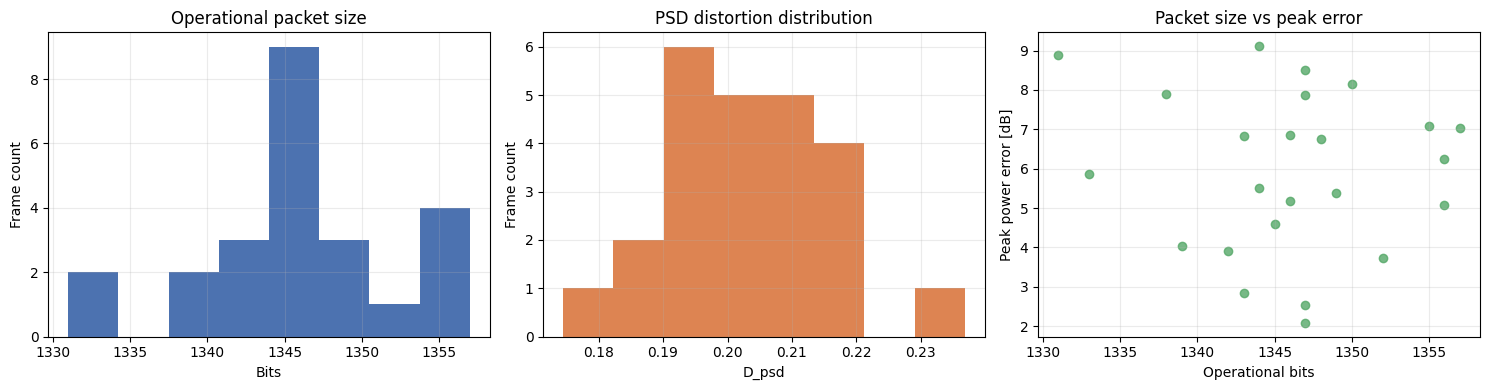

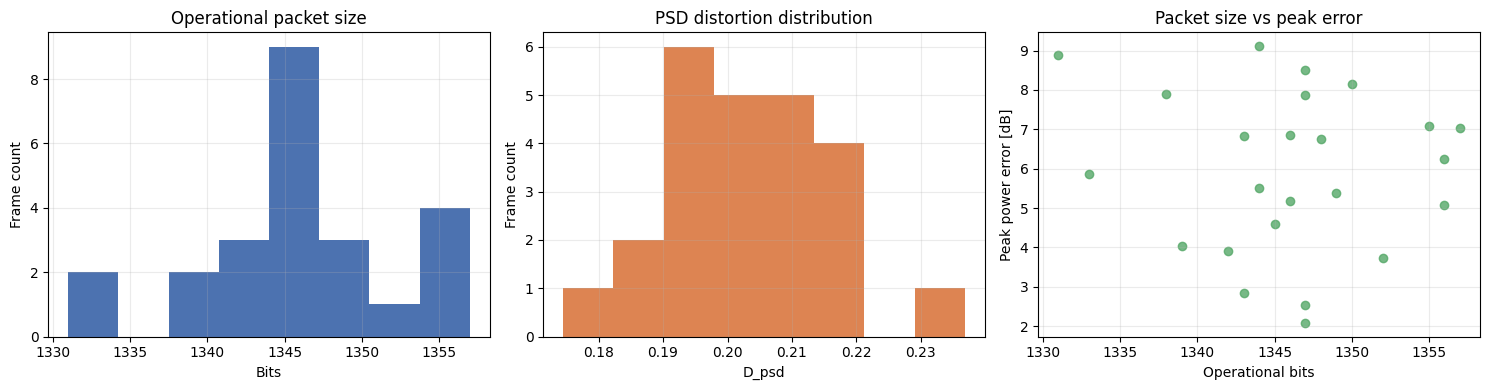

In [10]:
packet_bits = np.asarray(
    [frame_report.operational_bit_count for frame_report in batch_report.frame_reports],
    dtype=np.float64,
)
psd_distortions = np.asarray(
    [frame_report.psd_distortion for frame_report in batch_report.frame_reports],
    dtype=np.float64,
)
peak_power_errors_db = np.asarray(
    [frame_report.peak_power_error_db for frame_report in batch_report.frame_reports],
    dtype=np.float64,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(packet_bits, bins=min(8, batch_report.summary.frame_count), color="#4C72B0")
axes[0].set_title("Operational packet size")
axes[0].set_xlabel("Bits")
axes[0].set_ylabel("Frame count")
axes[0].grid(True, alpha=0.25)

axes[1].hist(
    psd_distortions,
    bins=min(8, batch_report.summary.frame_count),
    color="#DD8452",
)
axes[1].set_title("PSD distortion distribution")
axes[1].set_xlabel("D_psd")
axes[1].set_ylabel("Frame count")
axes[1].grid(True, alpha=0.25)

axes[2].scatter(packet_bits, peak_power_errors_db, color="#55A868", alpha=0.8)
axes[2].set_title("Packet size vs peak error")
axes[2].set_xlabel("Operational bits")
axes[2].set_ylabel("Peak power error [dB]")
axes[2].grid(True, alpha=0.25)
fig.tight_layout()
fig


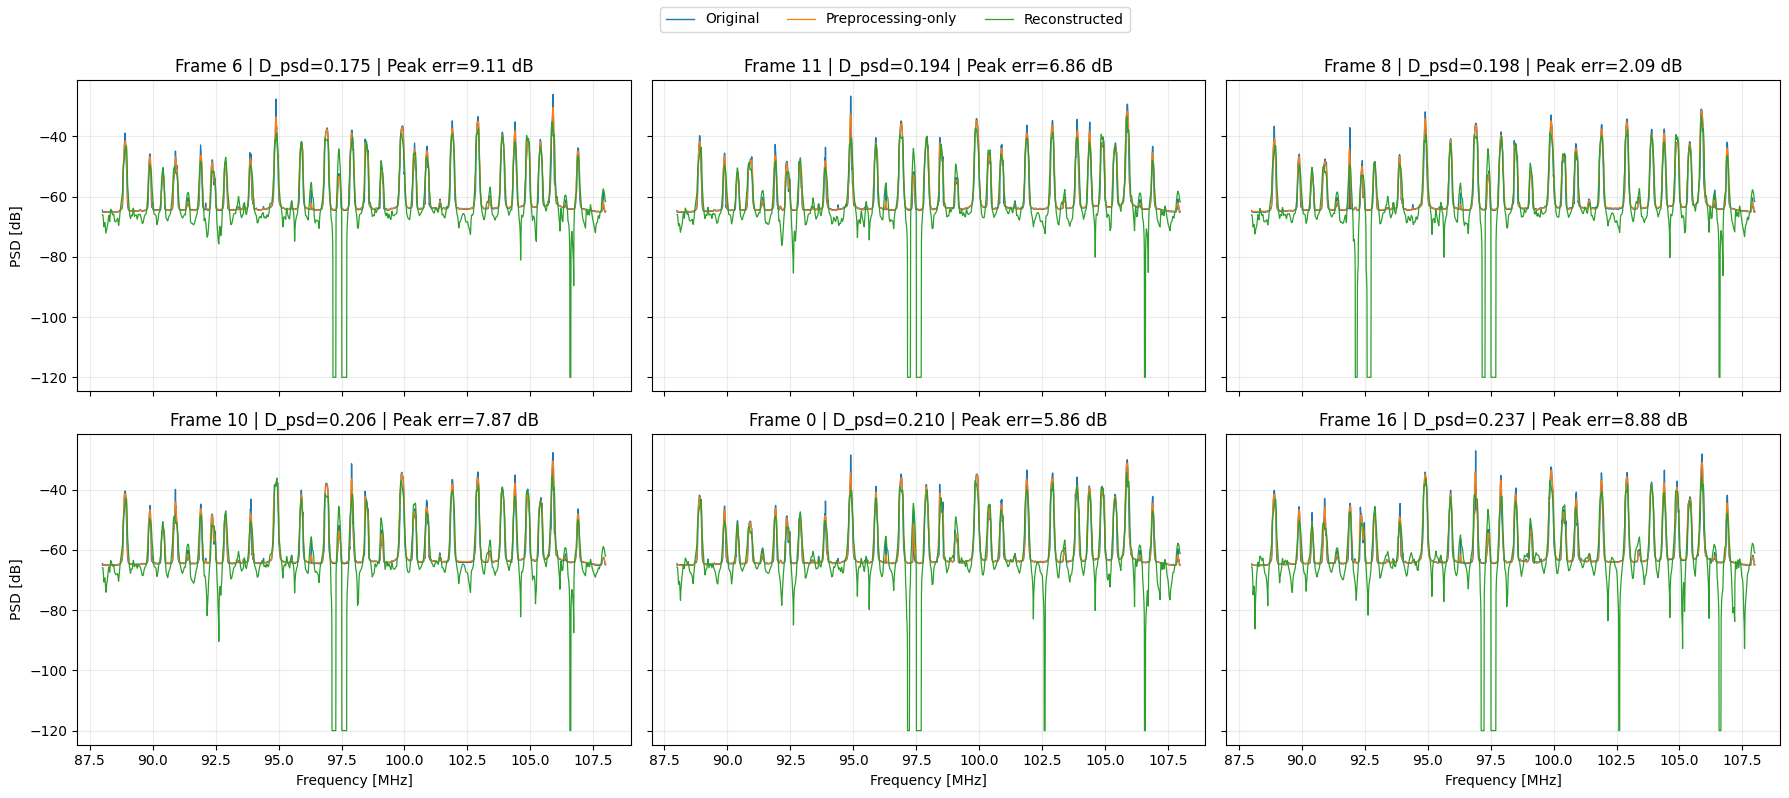

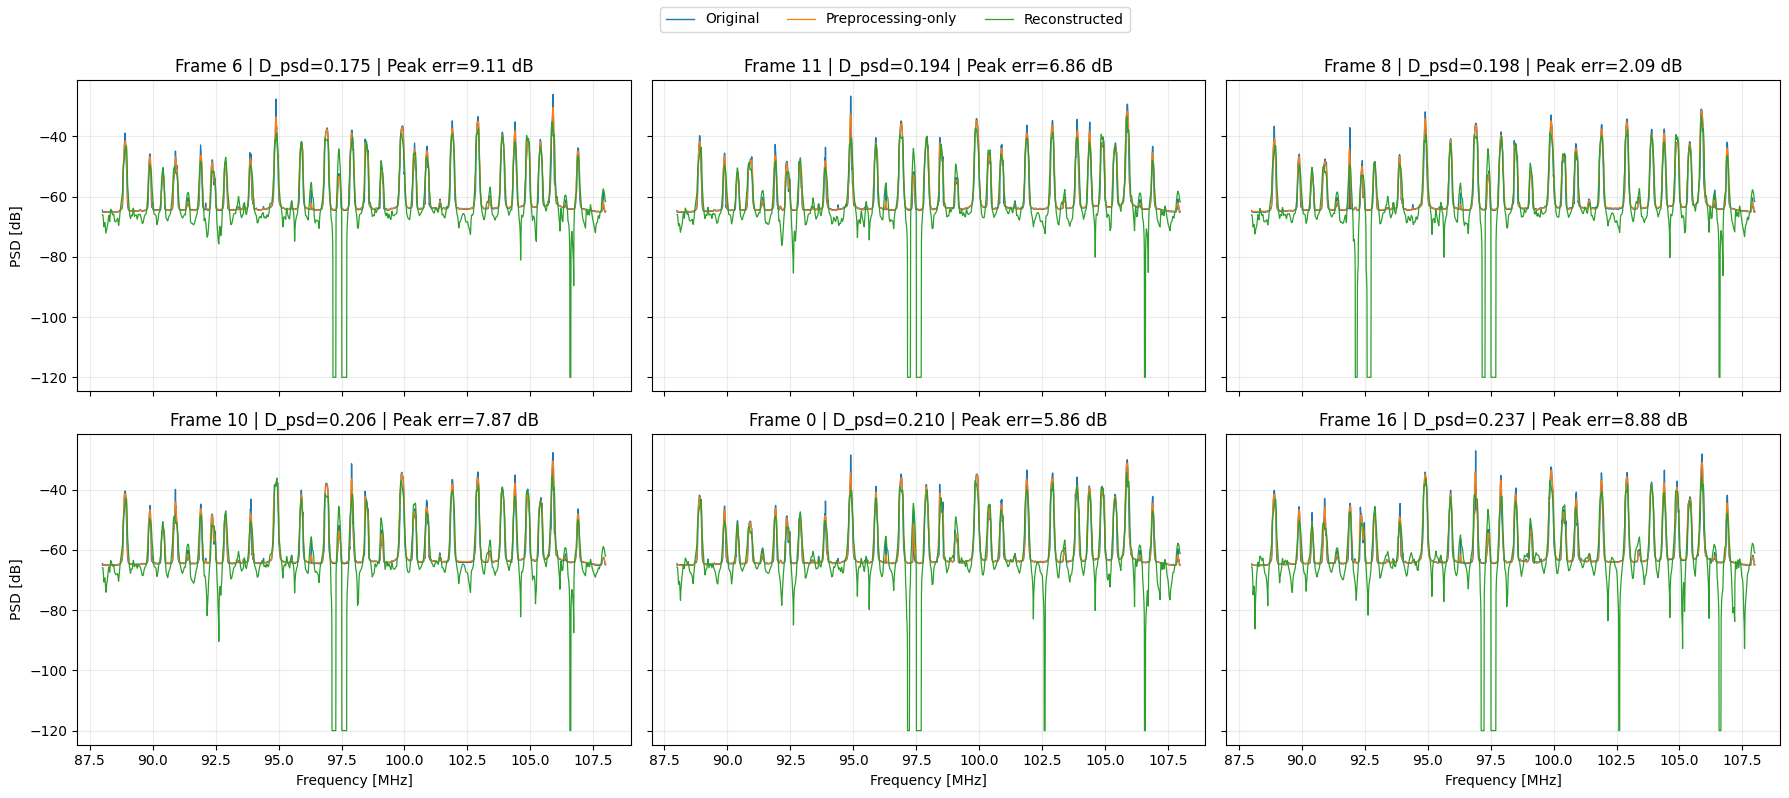

In [11]:
gallery_frames = select_gallery_frames(batch_report, gallery_size=6)
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
flat_axes = list(axes.flat)

for ax in flat_axes[len(gallery_frames) :]:
    ax.axis("off")

for ax, frame_report in zip(flat_axes, gallery_frames, strict=False):
    frequency_mhz = frame_report.frequency_grid_hz / 1.0e6
    ax.plot(frequency_mhz, to_db(frame_report.original_frame), label="Original", linewidth=1.0)
    ax.plot(
        frequency_mhz,
        to_db(frame_report.preprocessing_only_frame),
        label="Preprocessing-only",
        linewidth=0.9,
    )
    ax.plot(
        frequency_mhz,
        to_db(frame_report.reconstructed_frame),
        label="Reconstructed",
        linewidth=0.9,
    )
    ax.set_title(
        f"Frame {frame_report.frame_index} | D_psd={frame_report.psd_distortion:.3f} | "
        f"Peak err={frame_report.peak_power_error_db:.2f} dB"
    )
    ax.grid(True, alpha=0.25)

for ax in axes[-1, :]:
    ax.set_xlabel("Frequency [MHz]")
for ax in axes[:, 0]:
    ax.set_ylabel("PSD [dB]")

handles, labels = flat_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
fig


## Reading The Demo

This deployment demo is intentionally codec-first. The one-frame section answers whether the manuscript task survives the deployment path. The batch section answers whether the exported model is operationally stable and not just lucky on one acquisition. The most useful comparison is still `preprocessing-only` versus `full codec`: if the task terms and gallery worsen sharply only after the codec stage, the learned compression is the dominant source of task damage.
